In [33]:
!pip install wandb -q
import wandb
wandb.login()

True

In [34]:
import os
import pathlib, json, glob, shutil, zipfile
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras import Input, Model, layers
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint

In [35]:
data_path = pathlib.Path("data")
colab_path = pathlib.Path("/content/data")

if not data_path.exists() and not colab_path.exists():
    print("Data not found. Extracting from Drive...")
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    
    zip_src = pathlib.Path("/content/drive/MyDrive/data.zip")
    shutil.unpack_archive(zip_src, "/content") # Automatically handles unzipping
    data_path = colab_path
else:
    data_path = data_path if data_path.exists() else colab_path

df = pd.read_csv(data_path / "train.csv")
image_dir = data_path / "train_images" / "train_images"
test_image_dir = data_path / "test_images" / "test_images"
sample_submission_path = data_path / "sample_submission.csv"

In [36]:
le = LabelEncoder()
train_labels = le.fit_transform(df["TARGET"])
train_paths = df["file_name"].map(lambda name: str(image_dir / str(name))).to_numpy()

def process_path(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = tf.cast(img, tf.float32)
    label = tf.one_hot(label, depth=100)
    return img, label

AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 256

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = (train_ds
    .shuffle(buffer_size=len(train_paths))
    .map(process_path, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


In [37]:
data_augmentation = tf.keras.Sequential([
    layers.Rescaling(1.0 / 255, input_shape=(224, 224, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(factor=0.11),
    layers.RandomTranslation(height_factor=0.2, width_factor=0.2),
    layers.RandomZoom(height_factor=0.2, width_factor=0.2),
], name="data_augmentation")

def residual_block(x, filters, stride=1):
    shortcut = x

    x = layers.Conv2D(filters, 3, strides=stride, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    return layers.ReLU()(x)

def build_resnet18(input_shape=(224, 224, 3), num_classes=100):
    inputs = Input(shape=input_shape)
    x = data_augmentation(inputs)

    x = layers.Conv2D(64, 7, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding="same")(x)

    for filters, blocks, stride in [(64, 2, 1), (128, 2, 2), (256, 2, 2), (512, 2, 2)]:
        x = residual_block(x, filters, stride=stride)
        for _ in range(1, blocks):
            x = residual_block(x, filters)

    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)
    return Model(inputs, outputs, name="resnet18")

model_CNN = build_resnet18()

INITIAL_LR = 1e-3
EPOCHS = 150
STEPS_PER_EPOCH = tf.data.experimental.cardinality(train_ds).numpy()
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=INITIAL_LR,
    decay_steps=EPOCHS * STEPS_PER_EPOCH,
    alpha=0.0
)

model_CNN.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_CNN.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "resnet18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_7[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_60 (Conv2D)  │ (None, 112, 112,  │      9,408 │ data_augmentatio… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_60[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_51 (ReLU)     │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 56, 56,    │          0 │ re_lu_51[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_61 (Conv2D)  │ (None, 56, 56,    │     36,864 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_61[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_52 (ReLU)     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_62 (Conv2D)  │ (None, 56, 56,    │     36,864 │ re_lu_52[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_62[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_24 (Add)        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_53 (ReLU)     │ (None, 56, 56,    │          0 │ add_24[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, 56, 56,    │     36,864 │ re_lu_53[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_63[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_54 (ReLU)     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_64 (Conv2D)  │ (None, 56, 56,    │     36,864 │ re_lu_54[0][0]  

 Total params: 11,237,412 (42.87 MB)

 Trainable params: 11,227,812 (42.83 MB)

 Non-trainable params: 9,600 (37.50 KB)

In [38]:
wandb.init(
    project="ELEC378FinalProject",
    config={
        "learning_rate": INITIAL_LR,
        "architecture": "ResNet18",
        "dataset": "train_images",
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "optimizer": "Adam",
        "loss_function": "categorical_crossentropy",
        "scheduler": "CosineAnnealingLR",
        "scheduler_initial_learning_rate": INITIAL_LR,
        "scheduler_decay_steps": EPOCHS * STEPS_PER_EPOCH,
        "scheduler_alpha": 0.0
    }
)

In [39]:
wandb_callbacks = [
    WandbMetricsLogger(),
    WandbModelCheckpoint(
        filepath="best_resnet18_model.keras",
        monitor="loss",
        save_best_only=True
    )
]

history = model_CNN.fit(
    train_ds,
    epochs=EPOCHS,
    callbacks=wandb_callbacks
)

wandb.finish()

Epoch 1/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 242ms/step - accuracy: 0.1552 - loss: 3.6592
Epoch 2/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 209ms/step - accuracy: 0.3264 - loss: 2.5759
Epoch 3/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 208ms/step - accuracy: 0.4359 - loss: 2.1248
Epoch 4/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 209ms/step - accuracy: 0.5322 - loss: 1.7071
Epoch 5/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 209ms/step - accuracy: 0.6012 - loss: 1.4287
Epoch 6/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 209ms/step - accuracy: 0.6561 - loss: 1.2292
Epoch 7/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 208ms/step - accuracy: 0.6829 - loss: 1.1340
Epoch 8/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 208ms/step - accuracy: 0.7230 - loss: 0.9697
Epoch 9/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 208ms/step - accuracy: 0.7400 - loss: 0.9094
Epoch 10/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 210ms/step - accuracy: 0.7668 - loss: 0.8164
Epoch 11/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 209ms/step - accuracy: 0.7827 - loss: 0.7455
Epoch 12/150
50/50 ━━━━━━━━━━━

wandb: WARNING Artifact "run_b39wsywd_model" already exists with the same content. No new version will be created.


50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 209ms/step - accuracy: 0.8895 - loss: 0.3661
Epoch 24/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 208ms/step - accuracy: 0.8949 - loss: 0.3354
Epoch 25/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 210ms/step - accuracy: 0.9000 - loss: 0.3170
Epoch 26/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 209ms/step - accuracy: 0.9031 - loss: 0.3098
Epoch 27/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 210ms/step - accuracy: 0.9100 - loss: 0.2856
Epoch 28/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 208ms/step - accuracy: 0.9115 - loss: 0.2732
Epoch 29/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 210ms/step - accuracy: 0.9151 - loss: 0.2699
Epoch 30/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 209ms/step - accuracy: 0.9198 - loss: 0.2485
Epoch 31/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 195ms/step - accuracy: 0.9180 - loss: 0.2554
Epoch 32/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 210ms/step - accuracy: 0.9380 - loss: 0.1997
Epoch 33/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 195ms/step - accuracy: 0.9324 - loss: 0.2045
Epoch 34/150
50/50 ━━━━━━━━━━━━━━━

epoch/accuracy,▁▅▅▇▇▇▇▇▇▇▇▇████████████████████████████
epoch/epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
epoch/learning_rate,████████▇▇▇▆▆▅▅▅▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁
epoch/loss,█▇▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/accuracy,0.99817
epoch/epoch,149
epoch/learning_rate,0
epoch/loss,0.00495


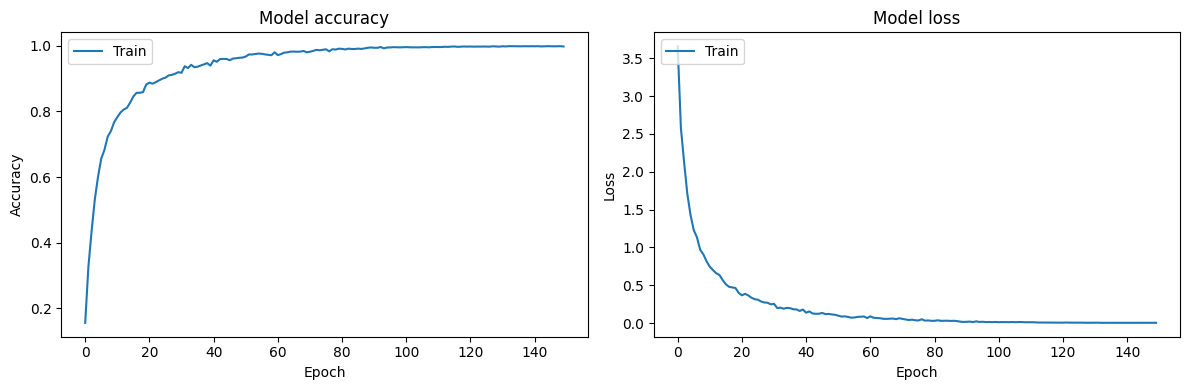

In [40]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')

plt.tight_layout()
plt.show()

In [43]:
test_df = pd.read_csv(sample_submission_path)
test_name_col = 'file_name' if 'file_name' in test_df.columns else 'ID'
test_paths = test_df[test_name_col].map(
    lambda name: str(test_image_dir / (str(name) if str(name).lower().endswith('.jpg') else f"{name}.jpg"))
).to_numpy()

def process_test_path(file_path):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = tf.cast(img, tf.float32)
    return img

test_ds = tf.data.Dataset.from_tensor_slices(test_paths)
test_ds = (test_ds
    .map(process_test_path, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

best_model = tf.keras.models.load_model('best_resnet18_model.keras')
predictions = best_model.predict(test_ds, verbose=1)
predicted_labels = le.inverse_transform(predictions.argmax(axis=1))

submission_df = test_df.copy()
submission_df['TARGET'] = predicted_labels
submission_df.to_csv('submission_full.csv', index=False)
submission_df.head()

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step


,ID,TARGET
0,test_000001,ADONIS
1,test_000002,ADONIS
2,test_000003,ADONIS
3,test_000004,ADONIS
4,test_000005,ADONIS


In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    drive_submission_path = pathlib.Path('/content/drive/MyDrive/submission.csv')
    submission_df.to_csv(drive_submission_path, index=False)
    print(f"Saved to Google Drive at {drive_submission_path}")
except ImportError:
    print("Saved locally.")
except Exception as e:
    print(f"Could not save to Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved submission.csv to Google Drive at /content/drive/MyDrive/submission.csv
